In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, f1_score


In [5]:
#załadowanie danych
df = pd.read_csv("./data/Heart_disease_cleveland_new.csv")
print(df.info())
print(df.describe())
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    2.158416  131.68976

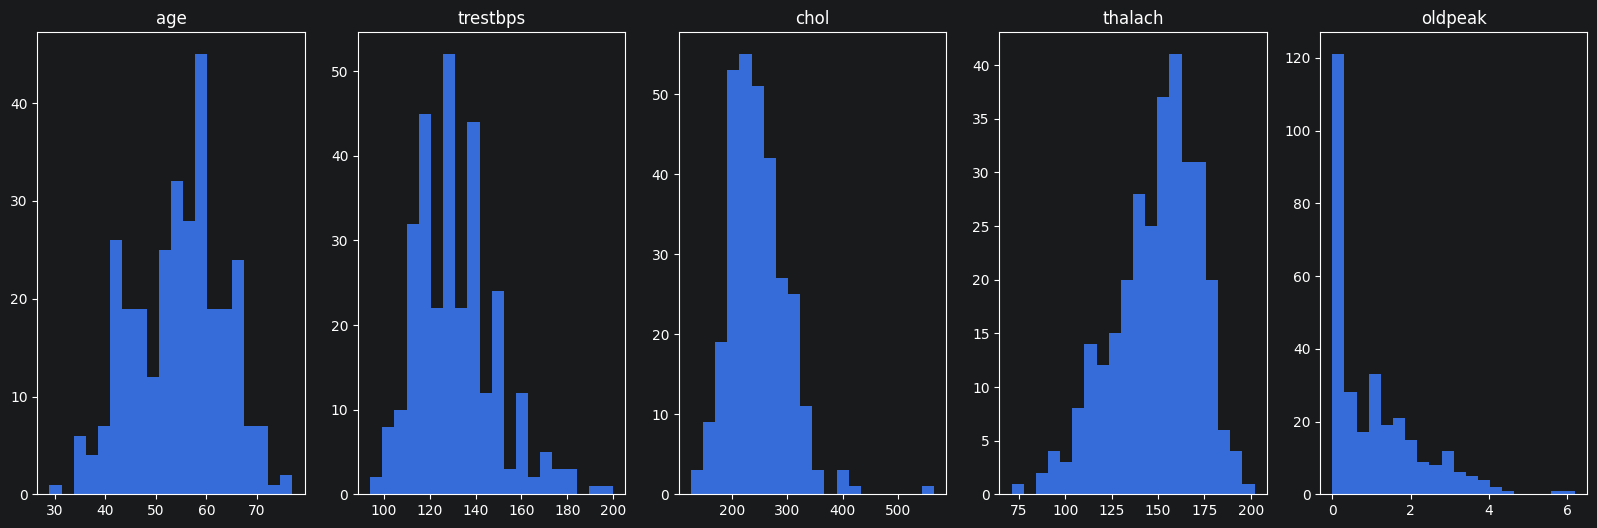

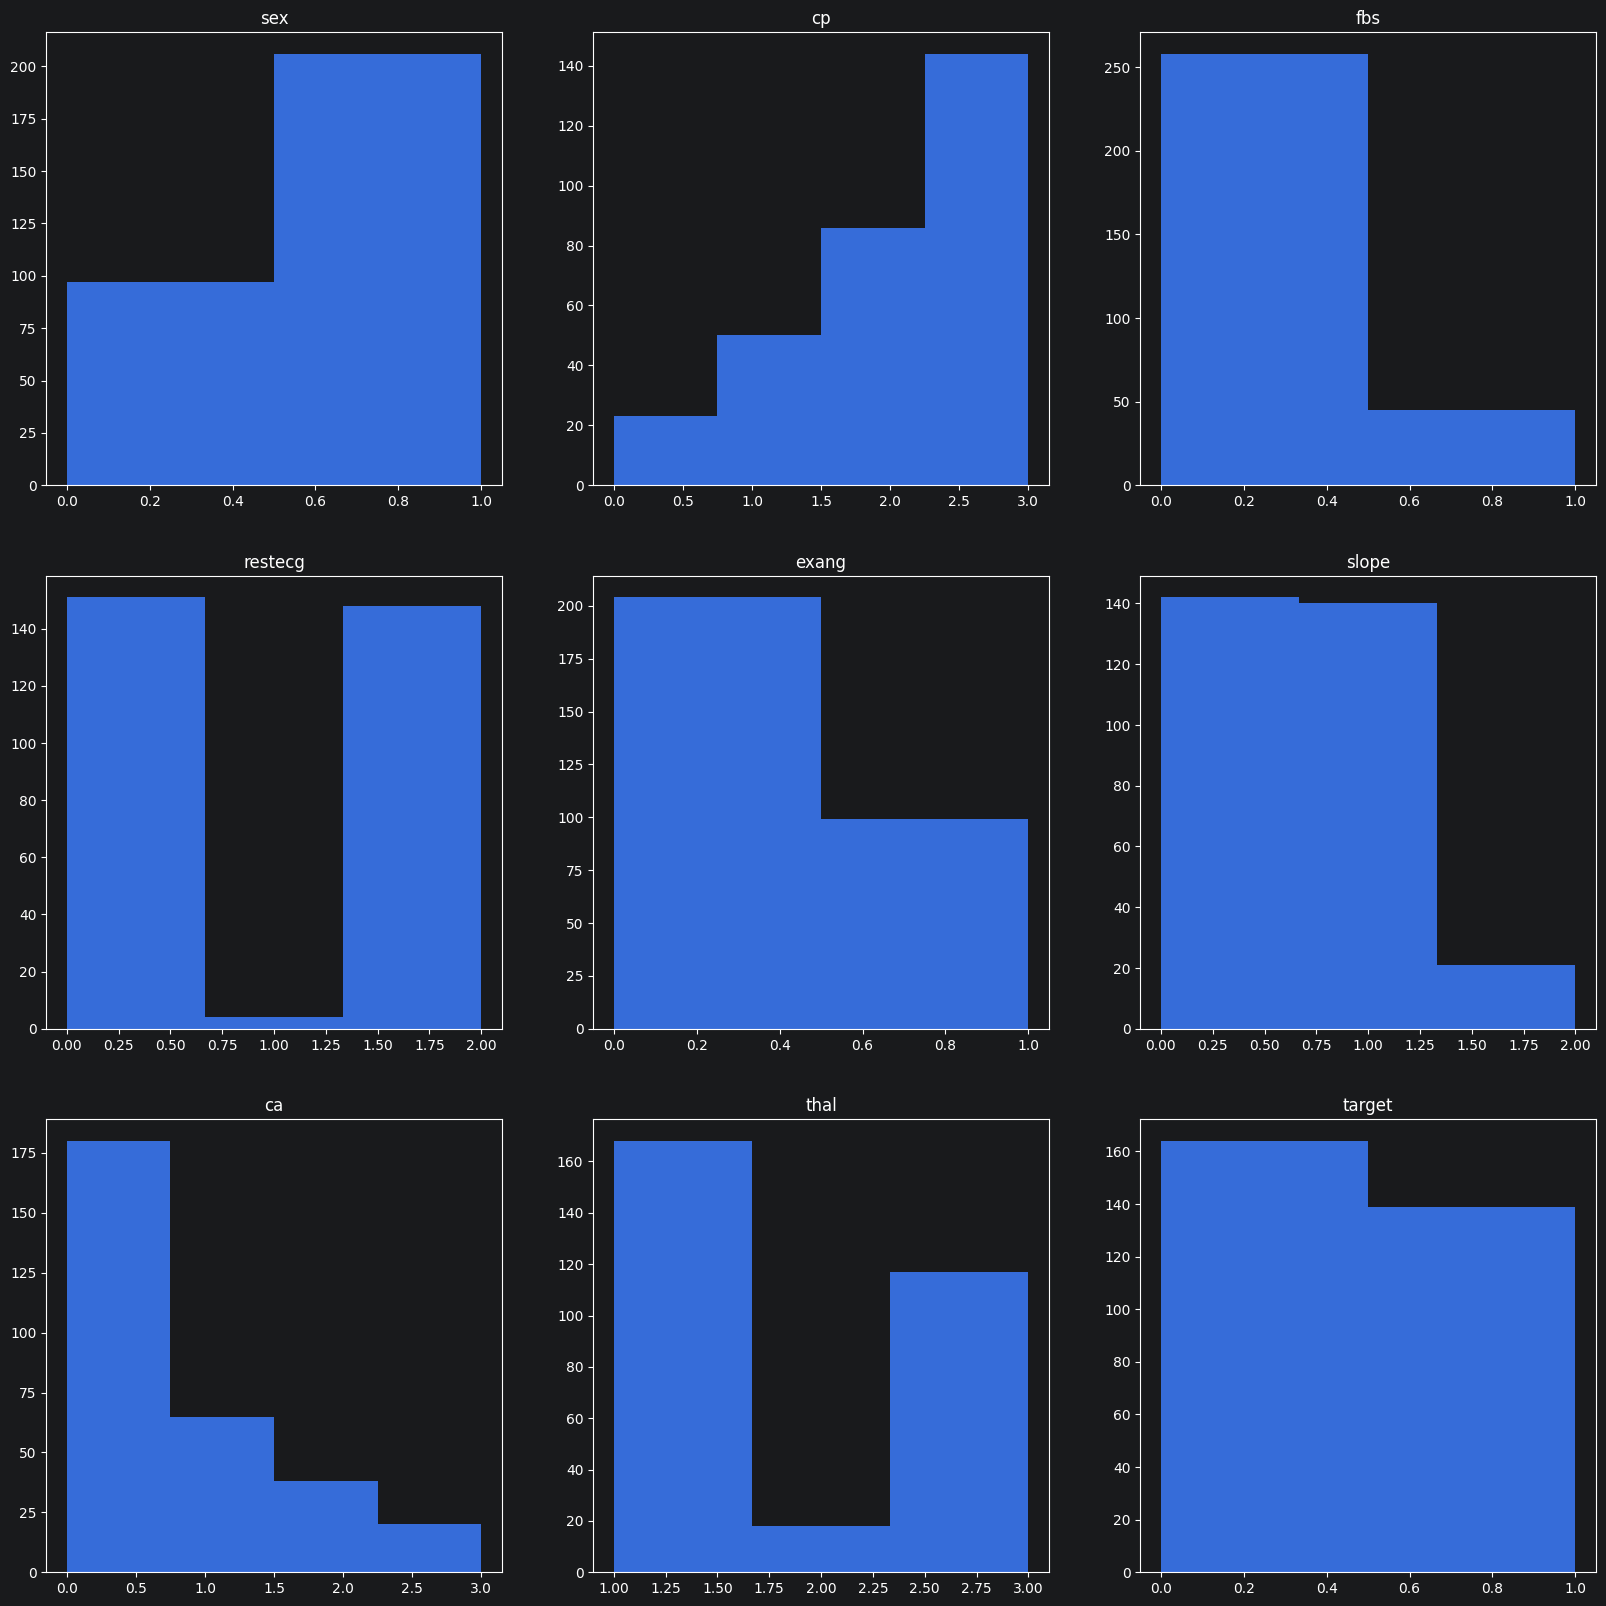

In [6]:
# rozkłady zmiennych
nominal_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
numerical_cols = [col for col in df.columns if col not in nominal_cols]
_, axes = plt.subplots(1, 5, figsize=(20, 6))
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    ax.hist(df[col], bins=20)
    ax.set_title(col)

_, axes = plt.subplots(3, 3, figsize=(20, 20))
for i, col in enumerate(nominal_cols):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=df[col].nunique())
    ax.set_title(col)

In [7]:
y = df["target"].values
X = df.drop("target", axis=1)



# One-hot encoding dla zmiennych nominalnych, z wyjątkiem "target" i tych, które mają tylko 2 unikalne wartości
ohe_cols = [col for col in nominal_cols if col != "target" and df[col].nunique() > 2]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)
encoder = OneHotEncoder(sparse_output=False, drop="first")
ohe = encoder.fit_transform(X_train[ohe_cols])
ohe_df = pd.DataFrame(ohe, columns=encoder.get_feature_names_out(ohe_cols), index=X_train.index)
# Dołączenie zakodowanych zmiennych do oryginalnego DataFrame
X_encoded = pd.concat([X_train.drop(ohe_cols, axis=1), ohe_df], axis=1)
X_encoded_without_standardization = X_encoded.copy()  # zachowanie wersji bez standaryzacji
# Standaryzacja zmiennych numerycznych
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

# Transformacja zbioru testowego
ohe_test = encoder.transform(X_test[ohe_cols])
ohe_test_df = pd.DataFrame(ohe_test, columns=encoder.get_feature_names_out(ohe_cols), index= X_test.index)
X_test_encoded = pd.concat([X_test.drop(ohe_cols, axis=1), ohe_test_df], axis=1)
X_test_encoded_without_standardization = X_test_encoded.copy()  # zachowanie wersji bez standaryzacji
X_test_encoded[numerical_cols] = scaler.transform(X_test_encoded[numerical_cols])
#sprawdzenie rozkładu klas w zbiorze treningowym i testowym
print("Rozkład klas w zbiorze treningowym:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nRozkład klas w zbiorze testowym:")
print(pd.Series(y_test).value_counts(normalize=True))

reg = LogisticRegression(max_iter=1000, random_state=42)
reg.fit(X_encoded, y_train)
y_pred = reg.predict(X_test_encoded)


Rozkład klas w zbiorze treningowym:
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Rozkład klas w zbiorze testowym:
0    0.540984
1    0.459016
Name: proportion, dtype: float64


In [8]:
def evaluate_model(y_test, y_pred, y_prob) -> None:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"Dokładność: {accuracy:.4f}")
    print(f"Precyzja: {precision:.4f}")
    print(f"Czułośc: {recall:.4f}")
    #macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    _, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Negatywne", "Pozytywne"])
    ax.set_yticklabels(["Negatywne", "Pozytywne"])
    ax.set_xlabel("Przewidywana klasa")
    ax.set_ylabel("Prawdziwa klasa")
    ax.set_title("Macierz pomyłek")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="red")
    # krzywa ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    _, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.plot(fpr, tpr, label="Regresja logistyczna")
    ax.set_xlabel("Odsetek fałszywie pozytywnych")
    ax.set_ylabel("Odsetek prawdziwie pozytywnych")
    ax.set_title("Krzywa ROC")

Dokładność: 0.8689
Precyzja: 0.8333
Czułośc: 0.8929


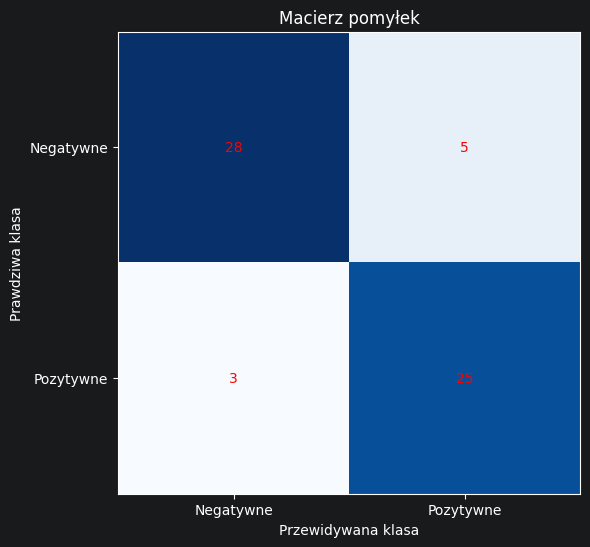

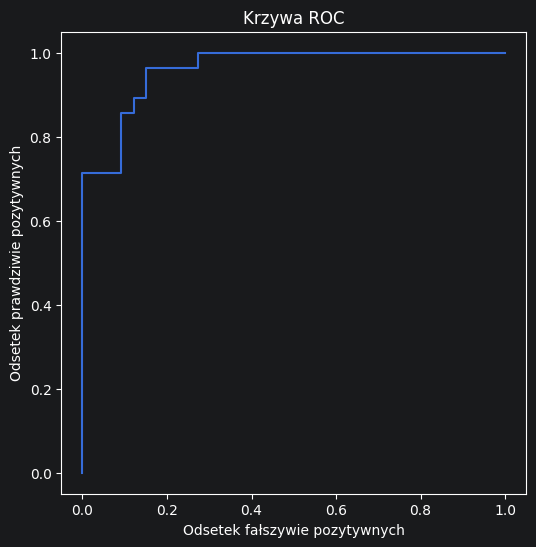

In [9]:
evaluate_model(y_test, y_pred, reg.predict_proba(X_test_encoded)[:, 1])

C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Dokładność: 0.8689
Precyzja: 0.8333
Czułośc: 0.8929


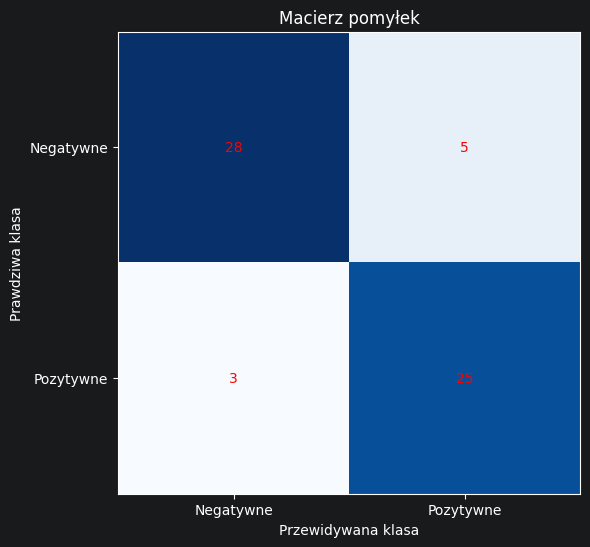

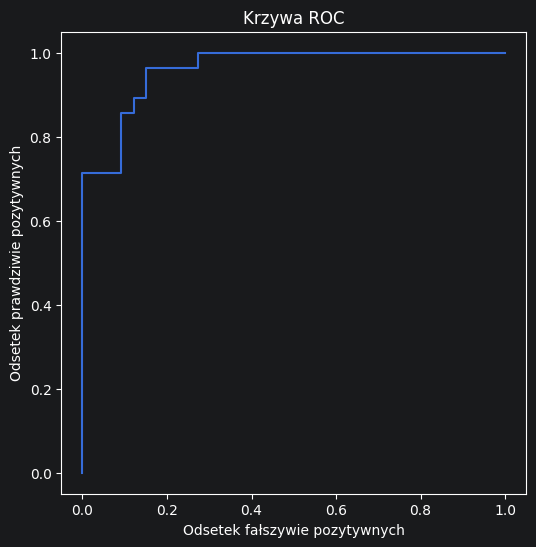

In [10]:
# Wytrenowanie klasyfikatora na danych bez standaryzacji i ocena
# Wytrenowanie klasyfikatora na danych bez standaryzacji i ocena
reg_no_scaling = LogisticRegression(max_iter=1000, random_state=42)
reg_no_scaling.fit(X_encoded_without_standardization, y_train)
y_pred_ns = reg_no_scaling.predict(X_test_encoded_without_standardization)
evaluate_model(
    y_test,
    y_pred_ns,
    reg_no_scaling.predict_proba(X_test_encoded_without_standardization)[:, 1]
)

Dokładność: 0.8689
Precyzja: 0.8333
Czułośc: 0.8929


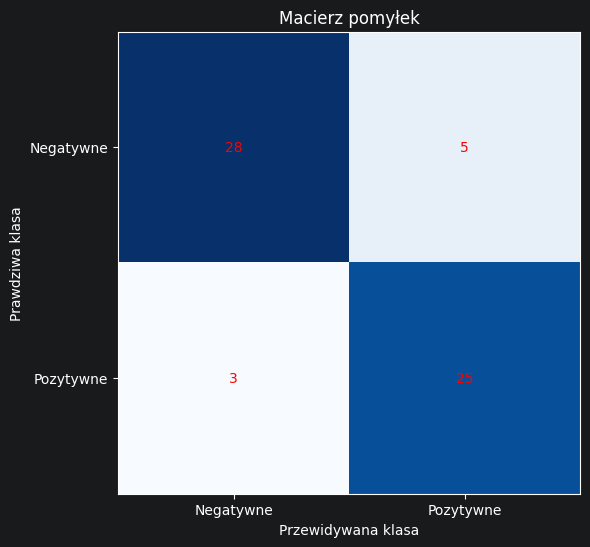

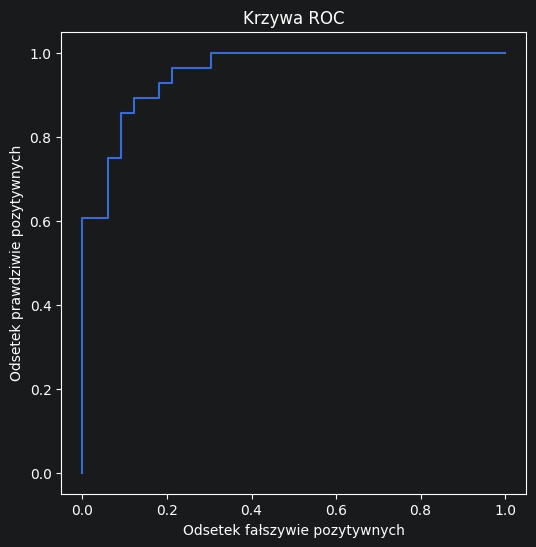

In [11]:
# tylko normalizacja - bez standaryzacji
X_train_norm = X_encoded_without_standardization.copy()
X_test_norm = X_test_encoded_without_standardization.copy()

normalizer = MinMaxScaler()
X_train_norm[numerical_cols] = normalizer.fit_transform(X_train_norm[numerical_cols])
X_test_norm[numerical_cols] = normalizer.transform(X_test_norm[numerical_cols])

reg_normalized = LogisticRegression(max_iter=1000, random_state=42)
reg_normalized.fit(X_train_norm, y_train)
y_pred_norm = reg_normalized.predict(X_test_norm)
evaluate_model(y_test, y_pred_norm, reg_normalized.predict_proba(X_test_norm)[:, 1])



Top 5 wg f1:
             C  l1_ratio        f1  accuracy  n_iter  convergence_warning
33   19.306977      0.75  0.866359  0.880165     238                False
29    3.727594      1.00  0.866359  0.880165     198                False
32   19.306977      0.50  0.866359  0.880165     236                False
36  100.000000      0.25  0.865116  0.880165    1217                False
38  100.000000      0.75  0.865116  0.880165    1321                False


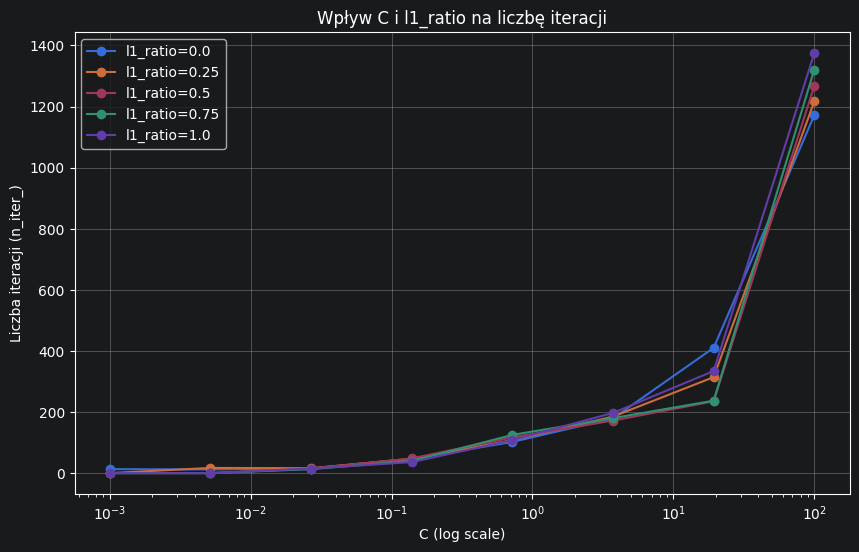

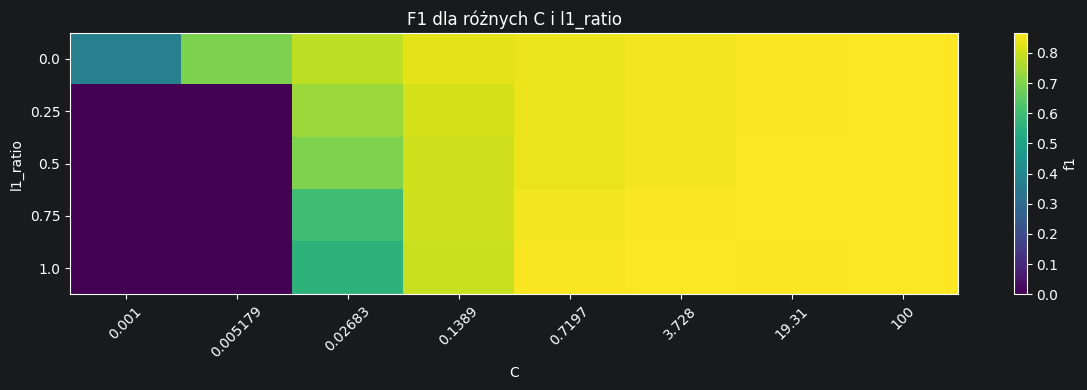

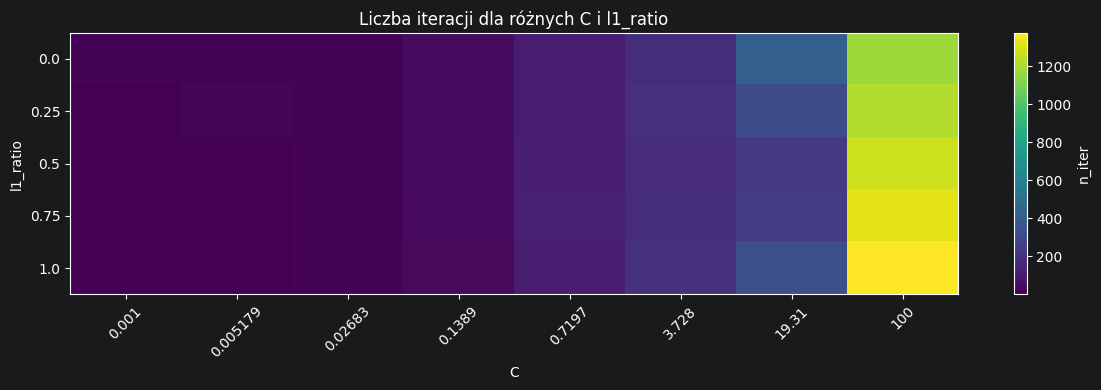

In [12]:
import warnings

from sklearn.exceptions import ConvergenceWarning

# Używamy danych już przygotowanych
# X_encoded, X_test_encoded, y_train, y_test

C_values = np.logspace(-3, 2, 8)  # 0.001 ... 100
l1_ratio_values = [0.0, 0.25, 0.5, 0.75, 1.0]  # 0=L2, 1=L1 (w elasticnet)

results = []

for C in C_values:
    for l1 in l1_ratio_values:
        model = LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            C=C,
            l1_ratio=l1,
            max_iter=5000,
            tol=1e-4,
            random_state=42
        )

        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always", ConvergenceWarning)
            model.fit(X_encoded, y_train)

        y_pred_train = model.predict(X_encoded)

        had_conv_warning = any(issubclass(w.category, ConvergenceWarning) for w in caught)
        n_iter = int(model.n_iter_[0])

        results.append({
            "C": C,
            "l1_ratio": l1,
            "accuracy": accuracy_score(y_train, y_pred_train),
            "precision": precision_score(y_train, y_pred_train, zero_division=0),
            "recall": recall_score(y_train, y_pred_train, zero_division=0),
            "f1": f1_score(y_train, y_pred_train, zero_division=0),
            "n_iter": n_iter,
            "convergence_warning": had_conv_warning,
            "hit_max_iter": n_iter >= model.max_iter
        })

results_df = pd.DataFrame(results)
print("\nTop 5 wg f1:")
print(results_df.sort_values("f1", ascending=False).head(5)[
          ["C", "l1_ratio", "f1", "accuracy", "n_iter", "convergence_warning"]
      ])

# Wykres: liczba iteracji vs C dla różnych l1_ratio
plt.figure(figsize=(10, 6))
for l1 in l1_ratio_values:
    sub = results_df[results_df["l1_ratio"] == l1].sort_values("C")
    plt.plot(sub["C"], sub["n_iter"], marker="o", label=f"l1_ratio={l1}")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Liczba iteracji (n_iter_)")
plt.title("Wpływ C i l1_ratio na liczbę iteracji")
plt.legend()
plt.grid(True)
plt.show()


# Heatmapy metryk
def plot_heatmap(metric_name, title):
    pivot = results_df.pivot(index="l1_ratio", columns="C", values=metric_name)
    plt.figure(figsize=(12, 4))
    im = plt.imshow(pivot.values, aspect="auto", cmap="viridis")
    plt.colorbar(im, label=metric_name)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.xticks(range(len(pivot.columns)), [f"{c:.4g}" for c in pivot.columns], rotation=45)
    plt.xlabel("C")
    plt.ylabel("l1_ratio")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_heatmap("f1", "F1 dla różnych C i l1_ratio")
plot_heatmap("n_iter", "Liczba iteracji dla różnych C i l1_ratio")


C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



StratifiedKFold - 2-fold CV:
accuracy: 0.8471 (+/- 0.0124)
precision: 0.8610 (+/- 0.0539)
recall: 0.8021 (+/- 0.0343)
f1: 0.8282 (+/- 0.0068)

KFold - 2-fold CV:
accuracy: 0.8017 (+/- 0.0248)
precision: 0.8139 (+/- 0.0403)
recall: 0.7388 (+/- 0.0067)
f1: 0.7742 (+/- 0.0219)


C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



StratifiedKFold - 5-fold CV:
accuracy: 0.8429 (+/- 0.0168)
precision: 0.8658 (+/- 0.0680)
recall: 0.7921 (+/- 0.0751)
f1: 0.8214 (+/- 0.0215)


C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


...

C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



StratifiedKFold - 10-fold CV:
accuracy: 0.8390 (+/- 0.0582)
precision: 0.8650 (+/- 0.1065)
recall: 0.7932 (+/- 0.0988)
f1: 0.8191 (+/- 0.0584)


C:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



KFold - 10-fold CV:
accuracy: 0.8260 (+/- 0.0698)
precision: 0.8365 (+/- 0.1114)
recall: 0.7732 (+/- 0.0908)
f1: 0.7993 (+/- 0.0845)


mean                                     std  \
metric                    accuracy        f1 precision    recall  accuracy   
cv_type         n_splits                                                     
KFold           2         0.801653  0.774205  0.813876  0.738799  0.024793   
                5         0.822364  0.799861  0.829584  0.774660  0.066449   
                10        0.826000  0.799318  0.836476  0.773207  0.069774   
StratifiedKFold 2         0.847107  0.828190  0.860956  0.802110  0.012397   
                5         0.842942  0.821354  0.865831  0.792095  0.016846   
                10        0.839000  0.819133  0.864957  0.793182  0.058244   

                                                        
metric                          f1 precision    recall  
cv_type         n_splits                                
KFold           2         0.021911  0.040291  0.006656  
                5         0.067534  0.073464  0.077585  
                10        0.084541  0.111378  0.090824  
StratifiedKFold 2         0.006761  0.053938  0.034253  
                5         0.021522  0.068037  0.075051  
                10        0.058362  0.106511  0.098779

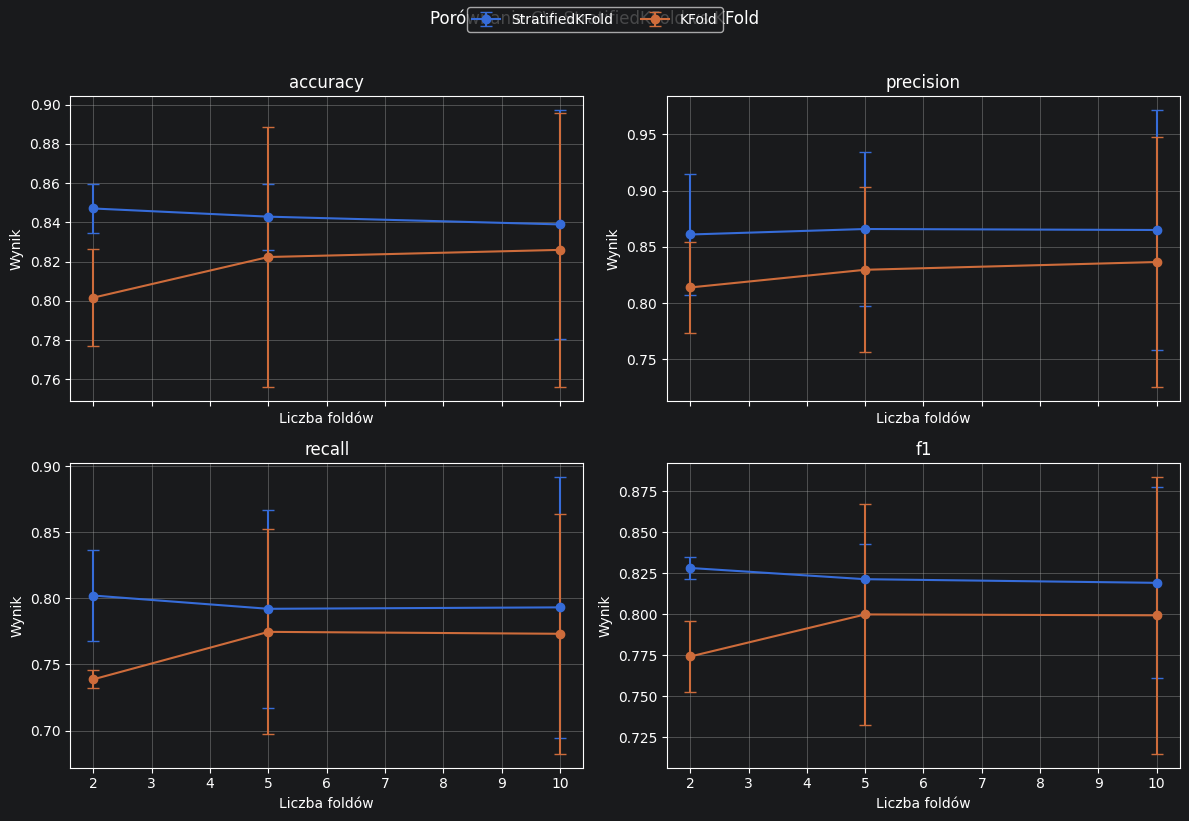

In [13]:
# walidacja krzyżowa 2-fold 5-fold 10-fold

cv_nominal_cols = [col for col in nominal_cols if col != "target"]
cv_ohe_cols = [col for col in cv_nominal_cols if df[col].nunique() > 2]
cv_num_cols = [col for col in X.columns if col not in cv_nominal_cols]

cv_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cv_num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cv_ohe_cols),
    ],
    remainder="passthrough"
)

cv_pipeline = Pipeline([
    ("prep", cv_preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# porównanie StratifiedKFold vs KFold
folds = [2, 5, 10]
scoring = ["accuracy", "precision", "recall", "f1"]
rows = []

for n in folds:
    cv_methods = {
        "StratifiedKFold": StratifiedKFold(n_splits=n, shuffle=True, random_state=42),
        "KFold": KFold(n_splits=n, shuffle=True, random_state=42),
    }
    for cv_name, cv_obj in cv_methods.items():
        cv_res = cross_validate(cv_pipeline, X_train, y_train, cv=cv_obj, scoring=scoring)
        print(f"\n{cv_name} - {n}-fold CV:")
        for metric in scoring:
            mean_val = cv_res[f"test_{metric}"].mean()
            std_val = cv_res[f"test_{metric}"].std()
            print(f"{metric}: {mean_val:.4f} (+/- {std_val:.4f})")
            rows.append({
                "cv_type": cv_name,
                "n_splits": n,
                "metric": metric,
                "mean": mean_val,
                "std": std_val,
            })

cv_summary_df = pd.DataFrame(rows)
display(cv_summary_df.pivot_table(index=["cv_type", "n_splits"], columns="metric", values=["mean", "std"]))

# proste wykresy mean +/- std dla metryk CV
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

for i, metric in enumerate(scoring):
    ax = axes[i]
    for cv_name in ["StratifiedKFold", "KFold"]:
        sub = cv_summary_df[(cv_summary_df["metric"] == metric) & (cv_summary_df["cv_type"] == cv_name)].sort_values("n_splits")
        ax.errorbar(sub["n_splits"], sub["mean"], yerr=sub["std"], marker="o", capsize=4, label=cv_name)
    ax.set_title(metric)
    ax.set_xlabel("Liczba foldów")
    ax.set_ylabel("Wynik")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Porównanie CV: StratifiedKFold vs KFold", y=1.02)
plt.tight_layout()
plt.show()


## Wnioski
Zbiór posiada zarówno zmienne numeryczne jak i nominalne, które wymagają odpowiedniego przygotowania przed trenowaniem modelu. Wykonałem one-hot encoding dla zmiennych nominalnych, a następnie standaryzację dla zmiennych numerycznych. Wytrenowanie na danych nie ustandaryzowanych dało podobne wyniki, jednak generalnie wymagało większej ilości iteracji do zbieżności, było to jednak testowane tylko dla jednego zestawu hiperparametrów. Analiza hiperparametrów C i l1_ratio pokazała znaczący wpływ na metryki modelu, a także na liczbę iteracji potrzebną do zbieżności. Generalnie konfiguracje, które dawały lepsze wyniki potrzbowaly więcej iteracji, a najgorzej działały hiperparametry - duże l1_ratio i małe C - czyli silna regularyzacja l1 - bo prowadzi ona często do zerowania wag. Wykonanie walidacji krzyżowej z różnymi liczbami foldów i porównanie StratifiedKFold z KFold pokazało, że stratified CV daje bardziej stabilne i lepsze wyniki dla użytych metryk. W tym przypadku precyzja oznaczała, jaka część przewidywanych pozytywnych przypadków była faktycznie pozytywna, a czułość - jaka część rzeczywistych pozytywnych przypadków została poprawnie zidentyfikowana przez model. F1-score, będący średnią harmoniczną precyzji i czułości, dał nam ogólny obraz jakości modelu, uwzględniając zarówno fałszywe pozytywy, jak i fałszywe negatywy.